In [2]:
from typing import TypedDict , Literal

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency : Literal["INR" , "EUR"]
    total: float

In [8]:
def cals_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state


def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 97
    return state

def convert_to_eur(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.9
    return state  

def choose_converstion(state : PortfolioState) -> str:
    return state["target_currency"]


In [14]:
from langgraph.graph import StateGraph , START , END

builder = StateGraph(PortfolioState)

builder.add_node("cals_total_node",cals_total)
builder.add_node("con_to_inr",convert_to_inr)
builder.add_node("con_to_eur",convert_to_eur)


builder.add_edge(START , "cals_total_node")
builder.add_conditional_edges(
    "cals_total_node",
    choose_converstion,
    {
        "INR" : "con_to_inr",
        "EUR" : "con_to_eur"
    }
)
builder.add_edge(["con_to_inr" , "con_to_eur"] , END)

graph = builder.compile()

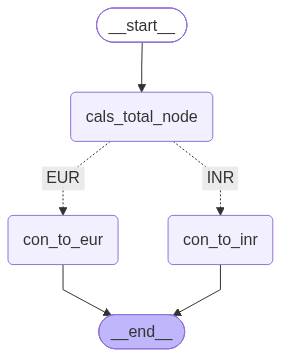

In [17]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))